In [60]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [61]:
df = pd.read_csv("placement.csv")

In [62]:
df.head()

,CGPA,Salary_Offered_LPA
0,6.0,5.1
1,6.1,5.6
2,6.2,6.2
3,6.3,6.4
4,6.4,7.0


In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CGPA                103 non-null    float64
 1   Salary_Offered_LPA  103 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


In [64]:
# Check for missing values
print(df.isnull().sum())

CGPA                  0
Salary_Offered_LPA    0
dtype: int64


In [65]:
df['Salary_Offered_LPA'] = df['Salary_Offered_LPA'].fillna(df['Salary_Offered_LPA'].mean())

In [66]:
print(df.isnull().sum())

CGPA                  0
Salary_Offered_LPA    0
dtype: int64


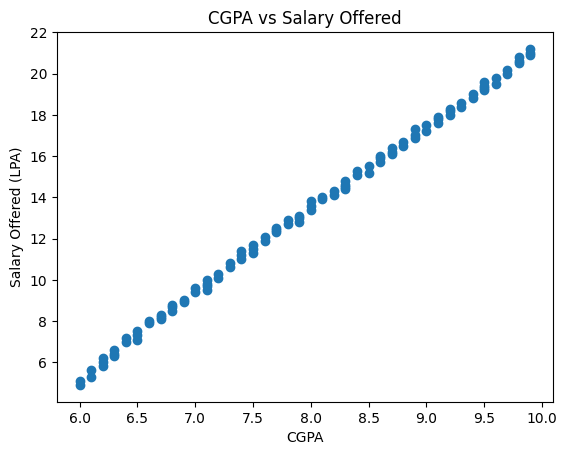

In [ ]:
plt.scatter(df['CGPA'], df['Salary_Offered_LPA'])
plt.xlabel('CGPA')
plt.ylabel('Salary Offered (LPA)')
plt.title('CGPA vs Salary Offered')
from sklearn.model_selection import train_test_splitplt.show()

In [68]:
from sklearn.model_selection import train_test_split
X = df[['CGPA']]
y = df['Salary_Offered_LPA']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [69]:
# import simple linear regression model
from sklearn.linear_model import LinearRegression
# Create an instance of the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [72]:
# import accuracy metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Make predictions on the test set
y_pred = model.predict(X_test)
# Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)
print(f'R^2 Score: {r2}')

R^2 Score: 0.9986334314621869


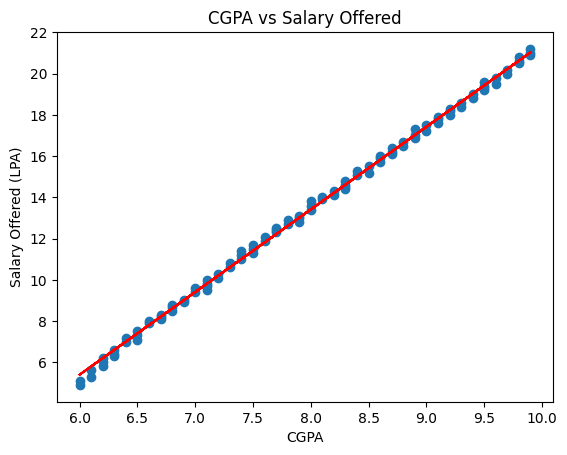

In [78]:
plt.scatter(df['CGPA'], df['Salary_Offered_LPA'])
plt.plot(df[['CGPA']], model.predict(df[['CGPA']]), color='red')  # Regression line
plt.xlabel('CGPA')
plt.ylabel('Salary Offered (LPA)')
plt.title('CGPA vs Salary Offered')
plt.show()

In [79]:
# slope and intercept b
print(f'Coefficient (slope): {model.coef_[0]}')
print(f'Intercept: {model.intercept_}')

Coefficient (slope): 4.009002084072621
Intercept: -18.657459373298664
